In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation
import math
import time

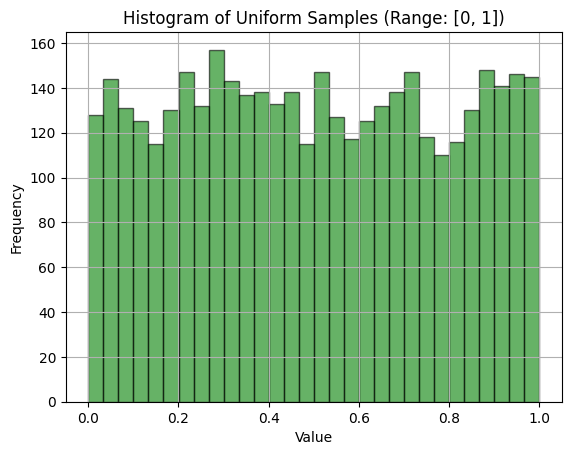

In [2]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

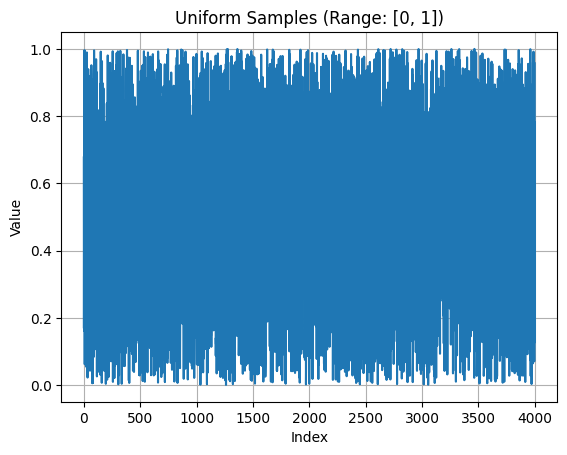

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

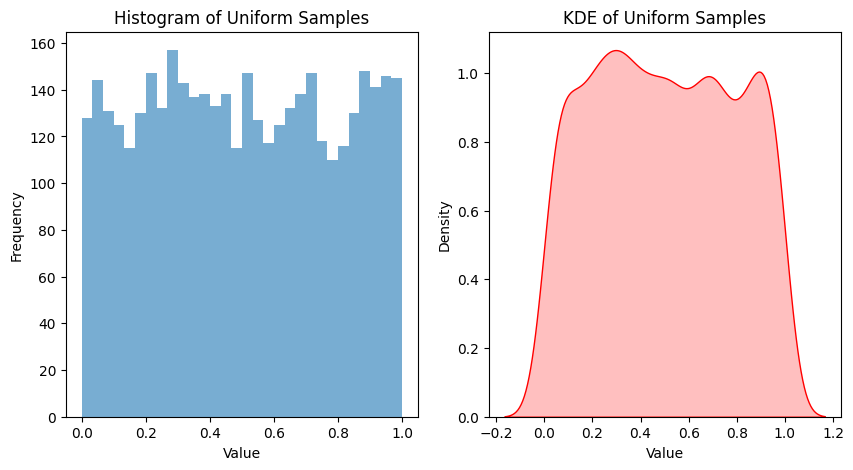

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

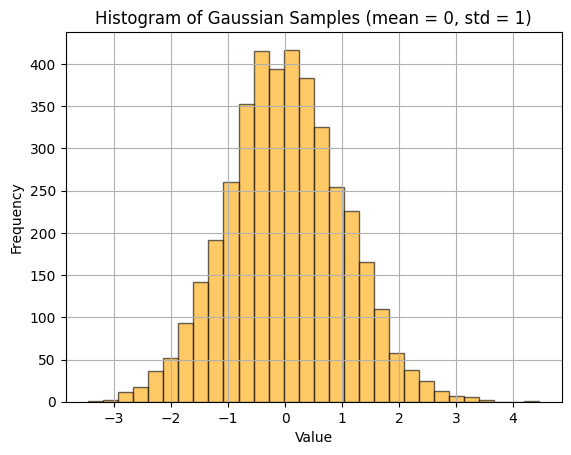

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

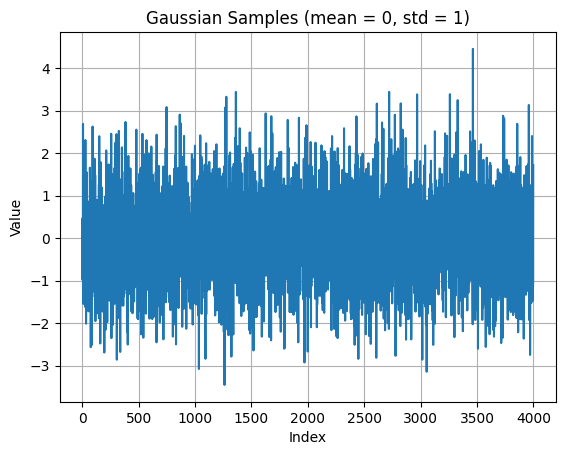

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

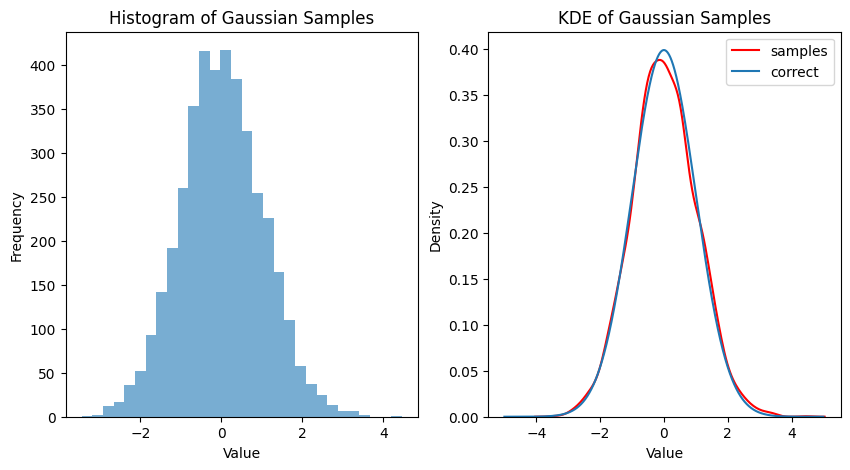

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')


# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

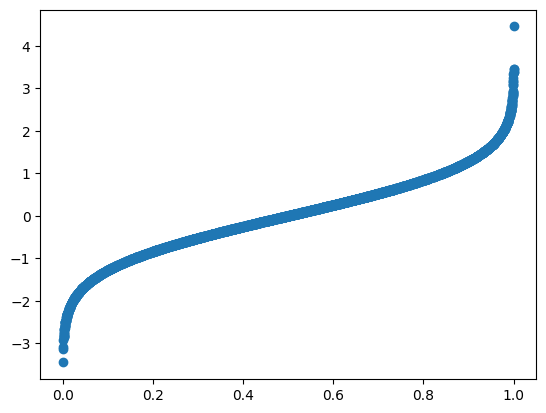

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, 64)
        self.fc6 = nn.Linear(64, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples)
    return variance

In [14]:
def compute_skewness(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    return skewness

In [15]:
def compute_kurtosis(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    return kurtosis

In [16]:
# Initialize the neural network
model = FNN()

In [17]:
class Model:
    def __init__(self, net, device="cpu"):
        self.net = net
        self.device = device
        self.iter = 0

        # Adaptive weights for AW method
        self.x_mean = None
        self.x_variance = None
        self.x_skewness = None
        self.x_kurtosis = None

        # Metrics storage
        self.mean_loss_list = []
        self.variance_loss_list = []
        self.skewness_loss_list = []
        self.kurtosis_loss_list = []
        self.total_loss_list = []
        self.epoch_list = []

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        with torch.no_grad():
            return self.train_U(x)

    def baseline_loss(self, outputs):
        mean_loss = (compute_mean(outputs) - 0) ** 2  # Mean of standard normal distribution is 0
        variance_loss = (compute_variance(outputs) - 1) ** 2  # Variance is 1
        skewness_loss = (compute_skewness(outputs) - 0) ** 2  # Skewness is 0
        kurtosis_loss = (compute_kurtosis(outputs) - 3) ** 2  # Kurtosis is 3
        total_loss = 5 * mean_loss + 10 * variance_loss + skewness_loss + kurtosis_loss
        return mean_loss, variance_loss, skewness_loss, kurtosis_loss, total_loss

    def likelihood_loss(self, mean_loss, variance_loss, skewness_loss, kurtosis_loss):
        loss = torch.reciprocal(2. * self.x_mean ** 2) * mean_loss.detach() + \
               torch.reciprocal(2. * self.x_variance ** 2) * variance_loss.detach() + \
               torch.reciprocal(2. * self.x_skewness ** 2) * skewness_loss.detach() + \
               torch.reciprocal(2. * self.x_kurtosis ** 2) * kurtosis_loss.detach() + \
               torch.log(self.x_mean * self.x_variance * self.x_skewness * self.x_kurtosis)
        return loss

    def true_loss(self, mean_loss, variance_loss, skewness_loss, kurtosis_loss):
        return torch.reciprocal(2. * self.x_mean.detach() ** 2) * mean_loss + \
               torch.reciprocal(2. * self.x_variance.detach() ** 2) * variance_loss +\
               torch.reciprocal(2. * self.x_skewness.detach() ** 2) * skewness_loss + \
               torch.reciprocal(2. * self.x_kurtosis.detach() ** 2) * kurtosis_loss

    def compute_mean(self, outputs):
        return torch.mean(outputs)

    def compute_variance(self, outputs):
        return torch.var(outputs)

    def run_baseline(self, num_epochs=10000, save_interval=10):
        optimizer = optim.Adam(self.net.parameters(), lr=0.001)

        for epoch in range(num_epochs):
            optimizer.zero_grad()

            # Generate uniform input
            uni_input = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
            uni_input = torch.tensor(uni_input).unsqueeze(1).to(self.device)

            # Forward pass
            outputs = self.train_U(uni_input)

            # Compute losses
            mean_loss, variance_loss, skewness_loss, kurtosis_loss, total_loss = self.baseline_loss(outputs)

            # Backward pass and optimization
            total_loss.backward()
            optimizer.step()

            # Store metrics
            self.mean_loss_list.append(mean_loss.item())
            self.variance_loss_list.append(variance_loss.item())
            self.skewness_loss_list.append(skewness_loss.item())
            self.kurtosis_loss_list.append(kurtosis_loss.item())
            self.total_loss_list.append(total_loss.item())
            self.epoch_list.append(epoch + 1)

            print(f'Epoch [{epoch + 1}/{num_epochs}], Mean Loss: {mean_loss.item():.4f}, '
                  f'Variance Loss: {variance_loss.item():.4f}, Skewness Loss: {skewness_loss.item():.4f}, '
                  f'Kurtosis Loss: {kurtosis_loss.item():.4f}, Total Loss: {total_loss.item():.4f}')


            # Early stopping
            if mean_loss <= 0.0001 and variance_loss <= 0.0001 and skewness_loss <= 0.0005 and kurtosis_loss <= 0.0005:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    def run_AW(self, num_epochs=10000, save_interval=10):
        self.x_mean = nn.Parameter(torch.tensor(2.0, requires_grad=True))
        self.x_variance = nn.Parameter(torch.tensor(2.0, requires_grad=True))
        self.x_skewness = nn.Parameter(torch.tensor(2.0, requires_grad=True))
        self.x_kurtosis = nn.Parameter(torch.tensor(2.0, requires_grad=True))

        optimizer_net = optim.Adam(self.net.parameters(), lr=0.001)
        optimizer_weights = optim.Adam([self.x_mean, self.x_variance, self.x_skewness, self.x_kurtosis], lr=0.001)

        for epoch in range(num_epochs):
            optimizer_net.zero_grad()

            # Generate uniform input
            uni_input = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
            uni_input = torch.tensor(uni_input).unsqueeze(1).to(self.device)

            # Forward pass
            outputs = self.train_U(uni_input)

            # Compute losses
            mean_loss = (compute_mean(outputs) - 0) ** 2
            variance_loss = (compute_variance(outputs) - 1) ** 2
            skewness_loss = (compute_skewness(outputs) - 0) ** 2
            kurtosis_loss = (compute_kurtosis(outputs) - 0) ** 2
            total_loss = self.true_loss(mean_loss, variance_loss, skewness_loss, kurtosis_loss)

            # Backward pass and optimization for network
            total_loss.backward()
            optimizer_net.step()

            # Update adaptive weights
            optimizer_weights.zero_grad()
            likelihood = self.likelihood_loss(mean_loss, variance_loss, skewness_loss, kurtosis_loss)
            likelihood.backward()
            optimizer_weights.step()

            # Store metrics
            self.mean_loss_list.append(mean_loss.item())
            self.variance_loss_list.append(variance_loss.item())
            self.skewness_loss_list.append(skewness_loss.item())
            self.kurtosis_loss_list.append(kurtosis_loss.item())
            self.total_loss_list.append(total_loss.item())
            self.epoch_list.append(epoch + 1)

            print(f'Epoch [{epoch + 1}/{num_epochs}], Mean Loss: {mean_loss.item():.4f}, '
                  f'Variance Loss: {variance_loss.item():.4f}, Skewness Loss: {skewness_loss.item():.4f}, '
                  f'Kurtosis Loss: {kurtosis_loss.item():.4f}, Total Loss: {total_loss.item():.4f}')


            # Early stopping
            if mean_loss <= 0.0001 and variance_loss <= 0.0001 and skewness_loss <= 0.0001 and kurtosis_loss <= 0.0001:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    def train(self, model_type=0):
        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AW()
        elapsed_time = time.time() - start_time
        print(f"Training completed in {elapsed_time:.2f} seconds.")


In [18]:
AWmodel = Model(net=model)

In [19]:
model_type = 1

In [20]:
AWmodel.train()

Epoch [1/10000], Mean Loss: 0.0200, Variance Loss: 0.9995, Skewness Loss: 0.0322, Kurtosis Loss: 1.4809, Total Loss: 11.6082
Epoch [2/10000], Mean Loss: 0.0034, Variance Loss: 0.9994, Skewness Loss: 0.1028, Kurtosis Loss: 1.1893, Total Loss: 11.3030
Epoch [3/10000], Mean Loss: 0.0001, Variance Loss: 0.9995, Skewness Loss: 0.2401, Kurtosis Loss: 0.9240, Total Loss: 11.1598
Epoch [4/10000], Mean Loss: 0.0024, Variance Loss: 0.9998, Skewness Loss: 0.7437, Kurtosis Loss: 0.2675, Total Loss: 11.0215
Epoch [5/10000], Mean Loss: 0.0042, Variance Loss: 1.0000, Skewness Loss: 1.6825, Kurtosis Loss: 0.4784, Total Loss: 12.1818
Epoch [6/10000], Mean Loss: 0.0032, Variance Loss: 0.9999, Skewness Loss: 0.9875, Kurtosis Loss: 0.0683, Total Loss: 11.0711
Epoch [7/10000], Mean Loss: 0.0016, Variance Loss: 0.9998, Skewness Loss: 0.3868, Kurtosis Loss: 0.9497, Total Loss: 11.3423
Epoch [8/10000], Mean Loss: 0.0021, Variance Loss: 0.9998, Skewness Loss: 0.6781, Kurtosis Loss: 0.4792, Total Loss: 11.1662


Epoch [95/10000], Mean Loss: 0.0003, Variance Loss: 0.9987, Skewness Loss: 0.8717, Kurtosis Loss: 0.1932, Total Loss: 11.0541
Epoch [96/10000], Mean Loss: 0.0003, Variance Loss: 0.9989, Skewness Loss: 0.9459, Kurtosis Loss: 0.1485, Total Loss: 11.0848
Epoch [97/10000], Mean Loss: 0.0002, Variance Loss: 0.9988, Skewness Loss: 0.9099, Kurtosis Loss: 0.1858, Total Loss: 11.0852
Epoch [98/10000], Mean Loss: 0.0001, Variance Loss: 0.9988, Skewness Loss: 0.8970, Kurtosis Loss: 0.1532, Total Loss: 11.0385
Epoch [99/10000], Mean Loss: 0.0000, Variance Loss: 0.9985, Skewness Loss: 0.7852, Kurtosis Loss: 0.2572, Total Loss: 11.0273
Epoch [100/10000], Mean Loss: 0.0001, Variance Loss: 0.9982, Skewness Loss: 0.6498, Kurtosis Loss: 0.4135, Total Loss: 11.0454
Epoch [101/10000], Mean Loss: 0.0002, Variance Loss: 0.9979, Skewness Loss: 0.6321, Kurtosis Loss: 0.3888, Total Loss: 11.0011
Epoch [102/10000], Mean Loss: 0.0002, Variance Loss: 0.9977, Skewness Loss: 0.5620, Kurtosis Loss: 0.5141, Total Los

Epoch [190/10000], Mean Loss: 0.0042, Variance Loss: 0.0735, Skewness Loss: 0.0385, Kurtosis Loss: 1.7072, Total Loss: 2.5015
Epoch [191/10000], Mean Loss: 0.0074, Variance Loss: 0.0367, Skewness Loss: 0.0504, Kurtosis Loss: 1.6662, Total Loss: 2.1209
Epoch [192/10000], Mean Loss: 0.0126, Variance Loss: 0.0035, Skewness Loss: 0.0599, Kurtosis Loss: 1.5551, Total Loss: 1.7132
Epoch [193/10000], Mean Loss: 0.0141, Variance Loss: 0.0028, Skewness Loss: 0.0783, Kurtosis Loss: 1.5522, Total Loss: 1.7289
Epoch [194/10000], Mean Loss: 0.0086, Variance Loss: 0.0252, Skewness Loss: 0.0693, Kurtosis Loss: 1.5242, Total Loss: 1.8882
Epoch [195/10000], Mean Loss: 0.0000, Variance Loss: 0.0319, Skewness Loss: 0.0525, Kurtosis Loss: 1.5617, Total Loss: 1.9333
Epoch [196/10000], Mean Loss: 0.0095, Variance Loss: 0.0232, Skewness Loss: 0.0321, Kurtosis Loss: 1.6474, Total Loss: 1.9587
Epoch [197/10000], Mean Loss: 0.0163, Variance Loss: 0.0206, Skewness Loss: 0.0374, Kurtosis Loss: 1.6203, Total Loss:

Epoch [285/10000], Mean Loss: 0.0025, Variance Loss: 0.0084, Skewness Loss: 0.5804, Kurtosis Loss: 0.3290, Total Loss: 1.0064
Epoch [286/10000], Mean Loss: 0.0040, Variance Loss: 0.0043, Skewness Loss: 0.5852, Kurtosis Loss: 0.3665, Total Loss: 1.0143
Epoch [287/10000], Mean Loss: 0.0005, Variance Loss: 0.0198, Skewness Loss: 0.5988, Kurtosis Loss: 0.2442, Total Loss: 1.0439
Epoch [288/10000], Mean Loss: 0.0014, Variance Loss: 0.0186, Skewness Loss: 0.6164, Kurtosis Loss: 0.2714, Total Loss: 1.0805
Epoch [289/10000], Mean Loss: 0.0008, Variance Loss: 0.0016, Skewness Loss: 0.6486, Kurtosis Loss: 0.2031, Total Loss: 0.8718
Epoch [290/10000], Mean Loss: 0.0046, Variance Loss: 0.0079, Skewness Loss: 0.6739, Kurtosis Loss: 0.1947, Total Loss: 0.9704
Epoch [291/10000], Mean Loss: 0.0008, Variance Loss: 0.0149, Skewness Loss: 0.6722, Kurtosis Loss: 0.2218, Total Loss: 1.0465
Epoch [292/10000], Mean Loss: 0.0062, Variance Loss: 0.0080, Skewness Loss: 0.6922, Kurtosis Loss: 0.1339, Total Loss:

Epoch [380/10000], Mean Loss: 0.0003, Variance Loss: 0.0137, Skewness Loss: 0.3345, Kurtosis Loss: 0.2891, Total Loss: 0.7619
Epoch [381/10000], Mean Loss: 0.0032, Variance Loss: 0.0212, Skewness Loss: 0.3536, Kurtosis Loss: 0.1737, Total Loss: 0.7550
Epoch [382/10000], Mean Loss: 0.0023, Variance Loss: 0.0024, Skewness Loss: 0.4413, Kurtosis Loss: 0.0798, Total Loss: 0.5568
Epoch [383/10000], Mean Loss: 0.0053, Variance Loss: 0.0543, Skewness Loss: 0.4398, Kurtosis Loss: 0.1307, Total Loss: 1.1400
Epoch [384/10000], Mean Loss: 0.0003, Variance Loss: 0.0000, Skewness Loss: 0.4026, Kurtosis Loss: 0.1448, Total Loss: 0.5492
Epoch [385/10000], Mean Loss: 0.0000, Variance Loss: 0.0264, Skewness Loss: 0.2778, Kurtosis Loss: 0.2968, Total Loss: 0.8384
Epoch [386/10000], Mean Loss: 0.0001, Variance Loss: 0.0206, Skewness Loss: 0.2617, Kurtosis Loss: 0.3056, Total Loss: 0.7736
Epoch [387/10000], Mean Loss: 0.0004, Variance Loss: 0.0001, Skewness Loss: 0.3502, Kurtosis Loss: 0.2368, Total Loss:

Epoch [474/10000], Mean Loss: 0.0020, Variance Loss: 0.0013, Skewness Loss: 0.0004, Kurtosis Loss: 0.0002, Total Loss: 0.0230
Epoch [475/10000], Mean Loss: 0.0000, Variance Loss: 0.0000, Skewness Loss: 0.0001, Kurtosis Loss: 0.0003, Total Loss: 0.0006
Early stopping at epoch 475
Training completed in 3.30 seconds.


In [21]:
def draw_loss(model):
    ### Plotting the training and the generalization error
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Error plot",fontsize=15) 
    plt.yscale('log')
    plt.plot(model.epoch_list, model.total_loss_list,'r',label='Training error')
    plt.xlabel(r'Training times $n$',fontsize=15)
    plt.ylabel(r'$l_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15)

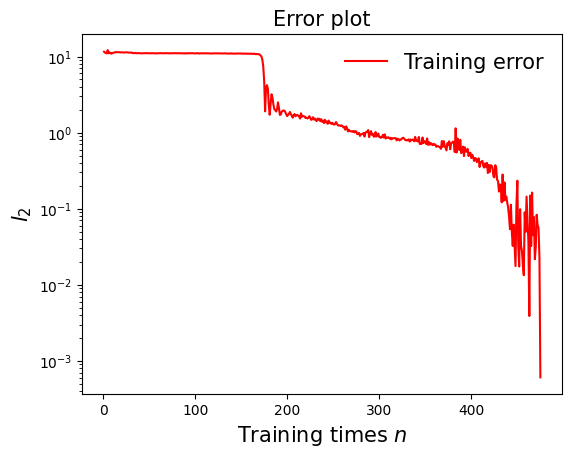

In [22]:
draw_loss(AWmodel)

In [23]:
def draw_errors(model):
    ### Plotting the training and the generalization error
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Error plot for loss functions w/o coeff",fontsize=15)
    plt.yscale('log')
    plt.plot(model.epoch_list, model.total_loss_list,'k',label='Training error')

    plt.plot(model.epoch_list, model.mean_loss_list,'r',label='mean error')

    plt.plot(model.epoch_list, model.variance_loss_list,'b',label='variance error')
    plt.plot(model.epoch_list, model.skewness_loss_list,'y',label='skewness error')

    plt.plot(model.epoch_list, model.kurtosis_loss_list,'g',label='kurtosis error')
    plt.xlabel(r'Training times $n$',fontsize=15)
    plt.ylabel(r'$l_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15, bbox_to_anchor=(1.1, 1.05))

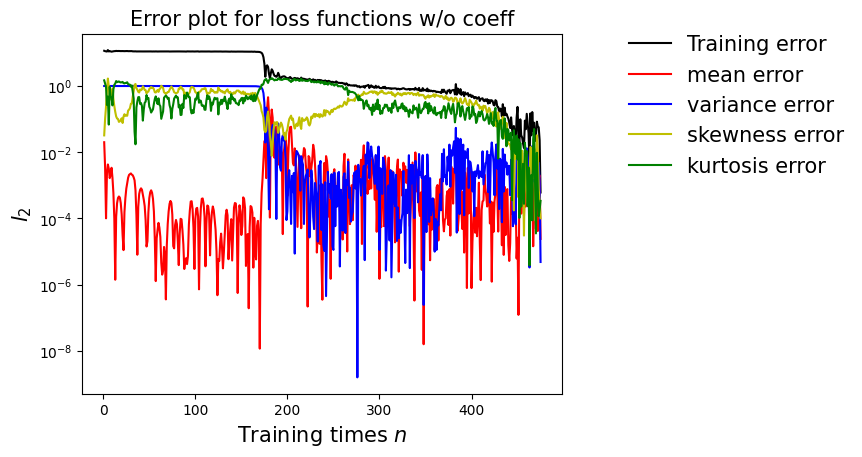

In [24]:
draw_errors(AWmodel)

In [25]:
from matplotlib.animation import FuncAnimation

# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [26]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

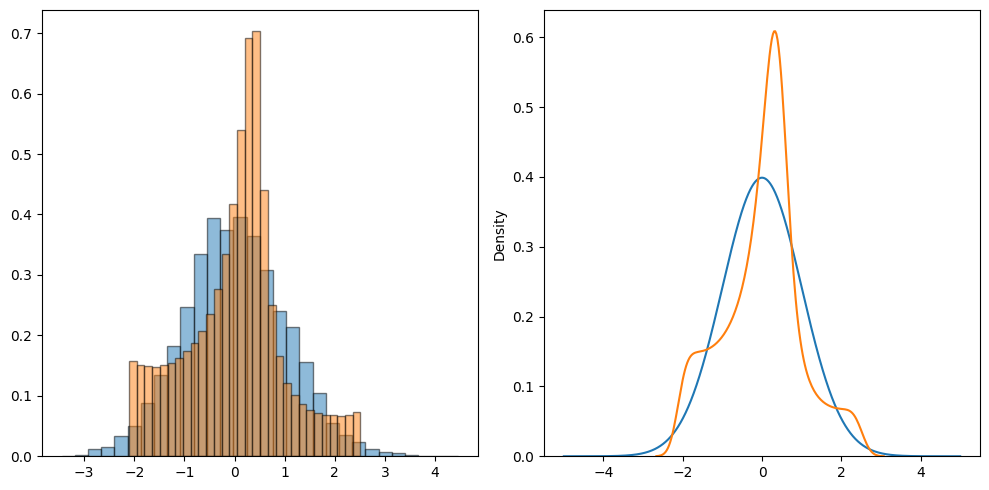

In [27]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

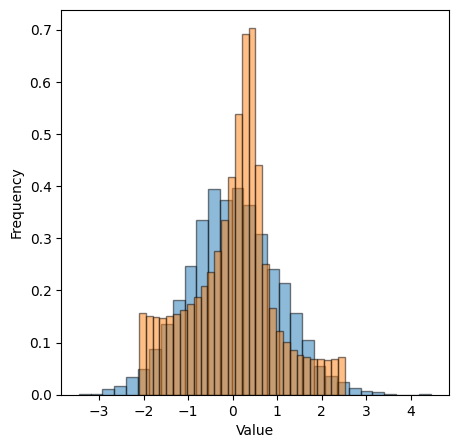

In [28]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

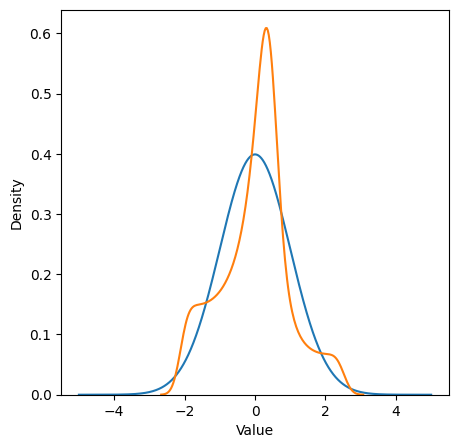

In [29]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')
# plt.ylim(0, 0.71)

In [30]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(torch.mean(transformed_samples1))
print(compute_variance(transformed_samples1))
print(compute_skewness(transformed_samples1))
print(compute_kurtosis(transformed_samples1))

tensor(0.0257)
tensor(0.9790)
tensor(0.0070)
tensor(-0.0047)


In [34]:
x_axis = np.arange(-5, 5, 0.0005)
print(compute_mean(gaussian_samples))
print(torch.var(gaussian_samples))
print(compute_skewness(gaussian_samples))
print(compute_kurtosis(gaussian_samples))

tensor(-0.0061, dtype=torch.float64)
tensor(1.0125, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)
tensor(-0.0033, dtype=torch.float64)
